# Plot model performance for single mice models

In [101]:
import os
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt

import seaborn as sns
import pandas as pd
npr.seed(0)
import os

from ssm.util import find_permutation


from plotting_utils import remove_top_right_frame, save_figure_to_files

In [102]:
# Load the data

root_path = r'M:\analysis\Axel_Bisi\beh_model'
result_figure_path = r'M:\analysis\Axel_Bisi\beh_model\all_subjects_glmhmm\figures'

subject_ids = [f for f in os.listdir(root_path) if 'AB' in f]

# Load the data
all_subjects_res = []
all_subjects_trial_data = []
splits = 1
best_k_state_model = '2_states'
for subject_id in subject_ids:
    for split_id in range(splits):
        path_to_res_folder = os.path.join(root_path, subject_id, 'full_models', f'model_{split_id}', best_k_state_model, 'iter_0')
        
        # Load model results
        path_to_res_file = os.path.join(path_to_res_folder,  'fit_glmhmm_results.npz')
        try:
            res = np.load(path_to_res_file, allow_pickle=True)['arr_0'][()]
            all_subjects_res.append(res)
        except:
            continue
            
        # Load trial data
        path_to_data_file = os.path.join(path_to_res_folder,  'data_preds.h5')
        try:
            trial_data = pd.read_hdf(path_to_data_file)
            all_subjects_trial_data.append(trial_data)
        except:
            continue
            

# Make dataframe
all_subjects_res = pd.DataFrame(all_subjects_res)
all_subjects_res.head()

all_subjects_trial_data = pd.concat(all_subjects_trial_data)
all_subjects_trial_data.head()

,mouse_id,wh_reward,behavior,session_id,day,trial_id,choice,prev_choice,stimulus_type,prev_stimulus_type,...,prev_stim_reward_given,prev_stim_auditory,prev_stim_whisker,reaction_time,bias,reward_group,split,pred,posterior_state_1,posterior_state_2
0,AB050,0,whisker,AB050_20230105_102940,0,0,0,0.0,0,0.0,...,0.0,0.0,0.0,0.0000,1,0.0,train,0,0.999997,0.000003
1,AB050,0,whisker,AB050_20230105_102940,0,1,0,0.0,1,0.0,...,0.0,0.0,0.0,0.0000,1,0.0,train,0,0.646040,0.353960
2,AB050,0,whisker,AB050_20230105_102940,0,2,1,0.0,-1,1.0,...,-1.0,-1.0,1.0,0.8228,1,0.0,train,1,0.381173,0.618827
3,AB050,0,whisker,AB050_20230105_102940,0,3,1,1.0,1,-1.0,...,1.0,1.0,-1.0,0.0689,1,0.0,train,0,0.136378,0.863622
4,AB050,0,whisker,AB050_20230105_102940,0,4,0,1.0,0,1.0,...,1.0,1.0,-1.0,0.0000,1,0.0,train,0,0.249681,0.750319


In [103]:
features = all_subjects_res['features'].values[0]
weights = all_subjects_res['weights'].values[0]
print(features, weights, weights.shape)

# Get model weights
weights_to_plot = 'weights'
weight_df = all_subjects_res[['subject_id', weights_to_plot, 'features']]
weight_df = weight_df.explode([weights_to_plot]).reset_index(drop=True)
weight_df[weights_to_plot] = weight_df[weights_to_plot].apply(lambda x: np.array(x.flatten()))
weight_df['state_idx'] = np.tile(np.array((0,1)).T, weight_df.subject_id.nunique())
weight_df = weight_df.explode([weights_to_plot,'features']).reset_index(drop=True)
weight_df

# Join weight df with reward group df
reward_group_mice = all_subjects_trial_data.groupby('mouse_id')['reward_group'].mean()
weight_df = weight_df.join(reward_group_mice, on='subject_id')

# Permute states based on model weights
# Identify state with highest absolute value for the 'auditory' feature (alternative, permute based on order of hit rates per trial type), for each mouse
highest_auditory_state = weight_df[weight_df.features=='auditory'].groupby('subject_id').apply(lambda x: x.loc[x.weights.abs().idxmax()]['state_idx'])
highest_auditory_state = pd.DataFrame(highest_auditory_state).reset_index()
highest_auditory_state.columns = ['mouse_id', 'highest_auditory_state']

highest_whisker_state = weight_df[weight_df.features=='whisker'].groupby('subject_id').apply(lambda x: x.loc[x.weights.abs().idxmax()]['state_idx'])
highest_whisker_state = pd.DataFrame(highest_whisker_state).reset_index()
highest_whisker_state.columns = ['mouse_id', 'highest_wh_state']

# In trial data, exchange pose of states based on highest auditory state
all_subjects_trial_data = all_subjects_trial_data.join(highest_auditory_state.set_index('mouse_id'), on='mouse_id')
all_subjects_trial_data = all_subjects_trial_data.join(highest_whisker_state.set_index('mouse_id'), on='mouse_id')
print(all_subjects_trial_data.columns)

# If highest auditory state is 1, exchange posterior columns 
all_subjects_trial_data.reset_index(drop=True, inplace=True)
all_subjects_trial_data['posterior_state_1_permut'] = np.nan
all_subjects_trial_data['posterior_state_2_permut'] = np.nan
order_state_by = 'highest_wh_state'
all_subjects_trial_data.loc[all_subjects_trial_data[order_state_by]==1, 'posterior_state_2_permut'] = all_subjects_trial_data['posterior_state_1']
all_subjects_trial_data.loc[all_subjects_trial_data[order_state_by]==1, 'posterior_state_1_permut'] = all_subjects_trial_data['posterior_state_2']
all_subjects_trial_data.loc[all_subjects_trial_data[order_state_by]==0, 'posterior_state_2_permut'] = all_subjects_trial_data['posterior_state_2']
all_subjects_trial_data.loc[all_subjects_trial_data[order_state_by]==0, 'posterior_state_1_permut'] = all_subjects_trial_data['posterior_state_1']





['bias', 'auditory', 'prev_stim_auditory', 'whisker', 'prev_stim_whisker', 'prev_stim_reward_given'] [[[-0.44942188 -2.91400695 -0.20933856  0.48352359  0.20933856
   -0.20933856]]

 [[-1.47158384 -3.30509483 -0.04863005 -1.1493597   0.04863005
   -0.04863005]]] (2, 1, 6)
Index(['mouse_id', 'wh_reward', 'behavior', 'session_id', 'day', 'trial_id',
       'choice', 'prev_choice', 'stimulus_type', 'prev_stimulus_type',
       'auditory', 'prev_auditory', 'whisker', 'prev_whisker', 'lick_correct',
       'is_stimulus', 'reward_given', 'prev_trial_reward_given',
       'prev_stim_reward_given', 'prev_stim_auditory', 'prev_stim_whisker',
       'reaction_time', 'bias', 'reward_group', 'split', 'pred',
       'posterior_state_1', 'posterior_state_2', 'highest_auditory_state',
       'highest_wh_state'],
      dtype='object')


In [104]:
# Create trial type column
all_subjects_trial_data['trial_type'] = 'no_stim'
all_subjects_trial_data.loc[all_subjects_trial_data.whisker==1, 'trial_type'] = 'whisker'
all_subjects_trial_data.loc[all_subjects_trial_data.auditory==1, 'trial_type'] = 'auditory'

# Assign most likely state to each trial based on posterior
#posterior_cols = [c for c in all_subjects_trial_data.columns if 'posterior' in c]
posterior_cols = [c for c in all_subjects_trial_data.columns if 'permut' in c]
print(posterior_cols)
all_subjects_trial_data['state'] = all_subjects_trial_data[posterior_cols].idxmax(axis=1).apply(lambda x: int(x.split('_')[-2])) # get integer
#all_subjects_trial_data['state'] = all_subjects_trial_data[posterior_cols].idxmax(axis=1).apply(lambda x: int(x.split('_')[-2])) # get integer before permut
all_subjects_trial_data


['posterior_state_1_permut', 'posterior_state_2_permut']


,mouse_id,wh_reward,behavior,session_id,day,trial_id,choice,prev_choice,stimulus_type,prev_stimulus_type,...,split,pred,posterior_state_1,posterior_state_2,highest_auditory_state,highest_wh_state,posterior_state_1_permut,posterior_state_2_permut,trial_type,state
0,AB050,0,whisker,AB050_20230105_102940,0,0,0,0.0,0,0.0,...,train,0,0.999997,0.000003,1,1,0.000003,0.999997,no_stim,2
1,AB050,0,whisker,AB050_20230105_102940,0,1,0,0.0,1,0.0,...,train,0,0.646040,0.353960,1,1,0.353960,0.646040,whisker,2
2,AB050,0,whisker,AB050_20230105_102940,0,2,1,0.0,-1,1.0,...,train,1,0.381173,0.618827,1,1,0.618827,0.381173,auditory,1
3,AB050,0,whisker,AB050_20230105_102940,0,3,1,1.0,1,-1.0,...,train,0,0.136378,0.863622,1,1,0.863622,0.136378,whisker,1
4,AB050,0,whisker,AB050_20230105_102940,0,4,0,1.0,0,1.0,...,train,0,0.249681,0.750319,1,1,0.750319,0.249681,no_stim,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26879,AB115,1,whisker,AB115_20240507_144758,2,213,1,0.0,-1,1.0,...,train,1,0.315327,0.684673,0,0,0.315327,0.684673,auditory,2
26880,AB115,1,whisker,AB115_20240507_144758,2,214,0,1.0,0,-1.0,...,test,0,0.893416,0.106584,0,0,0.893416,0.106584,no_stim,1
26881,AB115,1,whisker,AB115_20240507_144758,2,215,1,0.0,1,0.0,...,train,1,0.425483,0.574517,0,0,0.425483,0.574517,whisker,2
26882,AB115,1,whisker,AB115_20240507_144758,2,216,0,1.0,0,1.0,...,train,0,0.424313,0.575687,0,0,0.424313,0.575687,no_stim,2


# Plot single mouse performance across states

In [105]:

# For all mice, compute trial-specific lick rates
all_rates = []
data_sub = all_subjects_trial_data[all_subjects_trial_data.whisker==1]
rates_df = data_sub.groupby(['mouse_id', 'reward_group', 'session_id', 'day', 'state']).agg({'choice': 'mean'}).reset_index()
rates_df['trial_type'] = 'whisker'
all_rates.append(rates_df)
data_sub = all_subjects_trial_data[all_subjects_trial_data.auditory==1]
rates_df = data_sub.groupby(['mouse_id', 'reward_group', 'session_id', 'day','state']).agg({'choice': 'mean'}).reset_index()
rates_df['trial_type'] = 'auditory'
all_rates.append(rates_df)
data_sub = all_subjects_trial_data[(all_subjects_trial_data.whisker!=1) 
                                   &
                                  (all_subjects_trial_data.auditory!=1)]       
rates_df = data_sub.groupby(['mouse_id', 'reward_group', 'session_id', 'day','state']).agg({'choice': 'mean'}).reset_index()
rates_df['trial_type'] = 'no_stim'
all_rates.append(rates_df)

all_rates = pd.concat(all_rates)



Axes(0.125,0.11;0.352273x0.77)


C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


AttributeError: 'int' object has no attribute 'startswith'

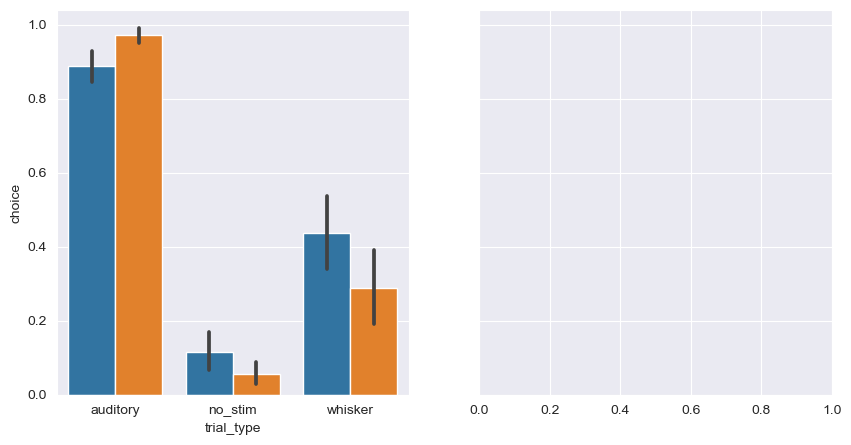

In [112]:
all_rates_day_0 = all_rates[all_rates.day==0]

fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for i, state in enumerate([1,2]): 

    ax = axs[i]
    print(ax)
    sns.barplot(data=all_rates_day_0[all_rates_day_0.state==state], x='trial_type', y='choice', 
                order=['auditory','no_stim','whisker'], hue='reward_group', hue_order=[1,0], ax=ax)
    ax.set_title(f'State {state}')
    ax.set_ylabel('P(lick)')
    ax.set_xlabel('Trial type')
    remove_top_right_frame(ax)
    

# Save figure
n_states = 2
file_name = f'permut_{n_states}_states_rates_all_subjects_split_{0}_'
save_figure_to_files(fig=fig, save_path=result_figure_path, file_name=file_name,
                     suffix=None, file_types=['png', 'svg'], dpi=200)


C:\Users\bisi\AppData\Local\Temp\ipykernel_25008\1563109312.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_rates_day_0['state'] = all_rates_day_0['state'].astype(str)
C:\Users\bisi\AppData\Local\Temp\ipykernel_25008\1563109312.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_rates_day_0['reward_group'] = all_rates_day_0['reward_group'].astype(str)
C:\Users\bisi\AppData\Local\Temp\ipykernel_25008\1563109312.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

AttributeError: 'int' object has no attribute 'startswith'

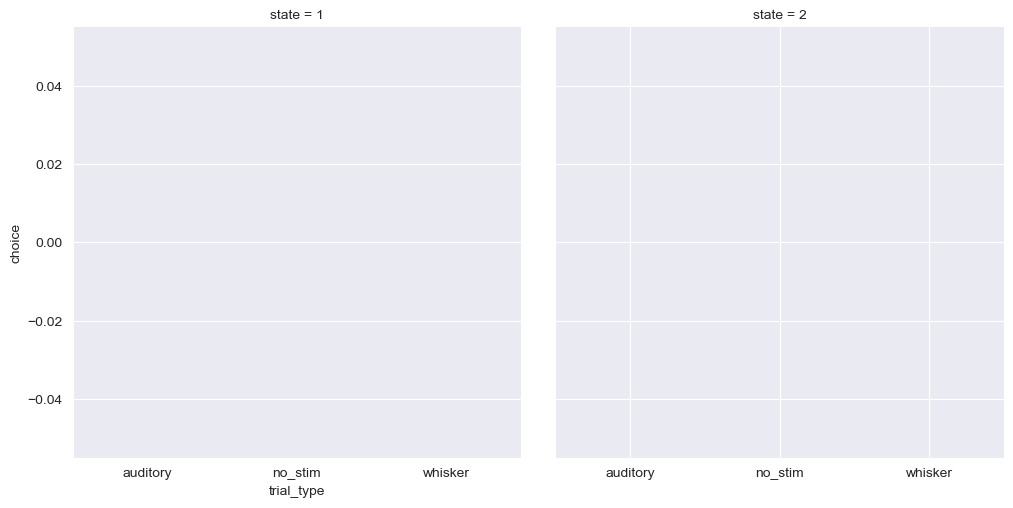

In [113]:
all_rates_day_0['state'] = all_rates_day_0['state'].astype(str)
all_rates_day_0['reward_group'] = all_rates_day_0['reward_group'].astype(str)
all_rates_day_0['trial_type'] = all_rates_day_0['trial_type'].astype(str)

sns.catplot(data=all_rates_day_0, kind='bar', x='trial_type', y='choice', hue='reward_group', hue_order=[1,0],
           col='state', order=['auditory','no_stim','whisker'])

In [ ]:
all_rates_day_0.state.unique()

mouse_id         object
reward_group     object
session_id       object
day              object
state            object
choice          float64
trial_type       object
dtype: object


C:\Users\bisi\AppData\Local\Temp\ipykernel_25008\1925054290.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_rates_day_0['state'] = all_rates_day_0['state'].astype(str)
C:\Users\bisi\AppData\Local\Temp\ipykernel_25008\1925054290.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_rates_day_0['reward_group'] = all_rates_day_0['reward_group'].astype(str)
C:\Users\bisi\AppData\Local\Temp\ipykernel_25008\1925054290.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

AttributeError: 'int' object has no attribute 'startswith'

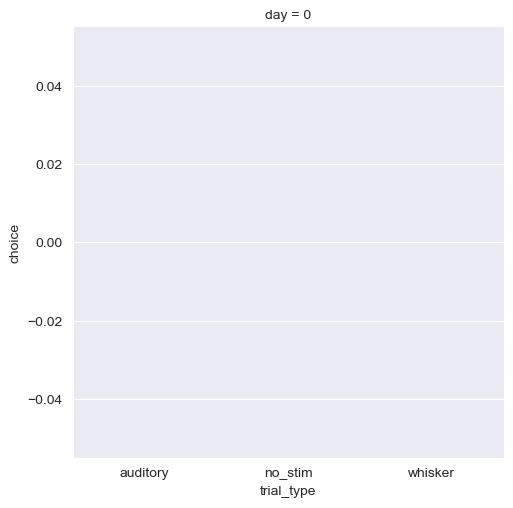

In [115]:
all_rates_day_0['state'] = all_rates_day_0['state'].astype(str)
all_rates_day_0['reward_group'] = all_rates_day_0['reward_group'].astype(str)
all_rates_day_0['trial_type'] = all_rates_day_0['trial_type'].astype(str)
all_rates_day_0['day'] = all_rates_day_0['day'].astype(str)
print(all_rates_day_0.dtypes)

sns.catplot(data=all_rates_day_0, kind='bar', x='trial_type', y='choice', hue='reward_group', hue_order=[1,0],
           col='day', order=['auditory','no_stim','whisker'])

In [116]:
all_rates_day_0

,mouse_id,reward_group,session_id,day,state,choice,trial_type
0,AB050,0.0,AB050_20230105_102940,0,1,0.269841,whisker
1,AB050,0.0,AB050_20230105_102940,0,2,0.000000,whisker
2,AB050,0.0,AB050_20230105_111358,0,1,0.285714,whisker
3,AB050,0.0,AB050_20230105_111358,0,2,0.125000,whisker
4,AB051,0.0,AB051_20230105_103830,0,1,0.714286,whisker
...,...,...,...,...,...,...,...
162,AB113,1.0,AB113_20240504_160955,0,2,0.638889,no_stim
167,AB114,1.0,AB114_20240505_142732,0,1,0.190476,no_stim
168,AB114,1.0,AB114_20240505_142732,0,2,0.202703,no_stim
173,AB115,1.0,AB115_20240505_160109,0,1,0.490909,no_stim


In [ ]:
# For all mice, compute state and trial-specific performance

all_perf = []
data_sub = all_subjects_trial_data[all_subjects_trial_data.state==1]
# Compute how many correct preds relative to choice
data_sub['correct'] = data_sub.choice == data_sub.pred
perf_df = data_sub.groupby(['mouse_id', 'session_id', 'day', 'trial_type']).agg({'correct': 'mean'}).reset_index()
perf_df['state'] = 1
all_perf.append(perf_df)

data_sub = all_subjects_trial_data[all_subjects_trial_data.state==2]
data_sub['correct'] = data_sub.choice == data_sub.pred
perf_df = data_sub.groupby(['mouse_id', 'session_id', 'day', 'trial_type']).agg({'correct': 'mean'}).reset_index()
perf_df['state'] = 2
all_perf.append(perf_df)

all_perf = pd.concat(all_perf)





In [ ]:
g = sns.catplot(data=all_perf, kind='bar',  x='trial_type', y='correct', col='state', row='day')

ax = g.axes[0][0]
ax.set_title('State 1')
ax = g.axes[0][1]
ax.set_title('State 2')
g.set_axis_labels('Trial type', 'Accuracy')


In [ ]:
occupancy_df = all_subjects_trial_data.groupby(['mouse_id', 'session_id', 'day'])['state'].value_counts(normalize=True).reset_index()
# Add reward group to occupancy df
occupancy_df = occupancy_df.join(reward_group_mice, on='mouse_id')
occupancy_df


In [ ]:
occupancy_df['proportion'] = occupancy_df['proportion'].astype(float)
occupancy_df['reward_group'] = occupancy_df['reward_group'].astype(int)
occupancy_df['state'] = occupancy_df['state'].astype(str)


g = sns.catplot(data=occupancy_df, kind='bar', x='reward_group', y='proportion', row='day',
                row_order=[0,1,2],
                order=[1,0], hue='state', palette=['forestgreen', 'green', 'crimson', 'firebrick'])

g.set_axis_labels('Reward group', 'Fraction of trials')

# Get figure and axes
fig = plt.gcf()

# Save figure
n_states = 2
file_name = f'permut_{n_states}_states_occupancy_all_subjects_split_{0}_'
save_figure_to_files(fig=fig, save_path=result_figure_path, file_name=file_name,
                     suffix=None, file_types=['png', 'svg'], dpi=200)